## Data Quality Analysis Summary

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
materials = pd.read_csv("../data/processed/materials.csv")
products = pd.read_csv("../data/processed/products.csv")


In [8]:
materials.shape
materials.columns
materials.dtypes
materials.head()

products.shape
products.columns
products.dtypes
products.head()


,product_id,product_name,category,product_weight,fragility_index,shipping_type
0,1,Cardboard Boxes,"E-commerce, Food & Beverage, Consumer Goods, A...",0.5,2,Standard
1,2,Protective Fillers (Paper/Biodegradable),"Fragile Items, Cosmetics, Pharmaceuticals, Int...",0.2,1,Standard
2,3,Steel Racks & Containers,"Heavy Industrial Components, High-Security Goods",2.0,5,Heavy
3,4,Protective Fillers (Paper/Biodegradable),"Fragile Items, Cosmetics, Pharmaceuticals, Int...",0.2,1,Standard
4,5,Protective Fillers (Paper/Biodegradable),"Fragile Items, Cosmetics, Pharmaceuticals, Int...",0.2,1,Standard


In [9]:
materials.describe()
products.describe()


,product_id,product_weight,fragility_index
count,404.000000,404.000000,404.000000
mean,202.500000,0.524752,2.400990
std,116.769003,0.425060,0.925299
min,1.000000,0.200000,1.000000
25%,101.750000,0.300000,2.000000
50%,202.500000,0.500000,2.000000
75%,303.250000,0.500000,3.000000
max,404.000000,2.000000,5.000000


In [10]:
materials.nunique()
products.nunique()

materials['material_type'].value_counts()
products['category'].value_counts()


category
E-commerce, Food & Beverage, Consumer Goods, Apparel                        139
Industrial Components, Heavy Machinery, Automotive Parts                    112
Electronics, Medium-Value Goods, Retail Logistics                            57
Fragile Items, Cosmetics, Pharmaceuticals, Internal Component Protection     37
Low-Value Goods, Secondary Protection for Non-Fragile Items                  30
Heavy Industrial Components, High-Security Goods                             29
Name: count, dtype: int64

In [11]:
materials.isna().sum()
products.isna().sum()


product_id         0
product_name       0
category           0
product_weight     0
fragility_index    0
shipping_type      0
dtype: int64

In [13]:
missing = pd.DataFrame({
    "materials_missing": materials.isna().sum(),
    "products_missing": products.isna().sum()
})
missing.to_csv("missing_value_table.csv")


In [14]:
materials.duplicated().sum()
products.duplicated().sum()


np.int64(0)

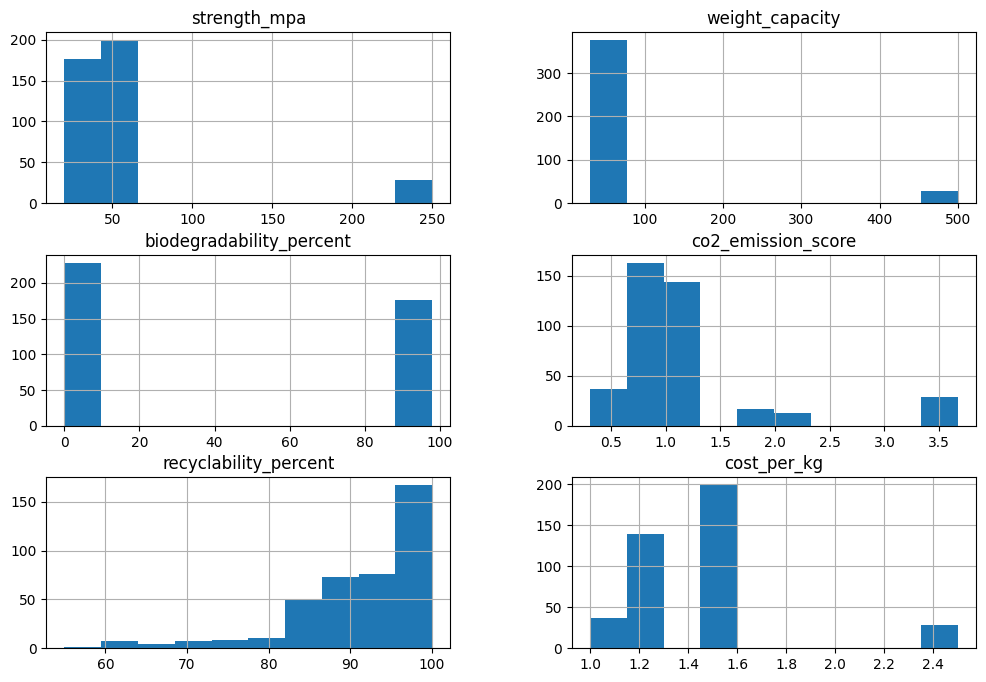

In [16]:
materials.hist(figsize=(12,8))
plt.show()


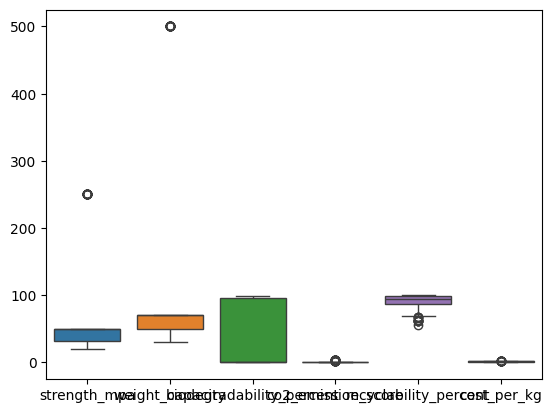

In [17]:
sns.boxplot(data=materials)
plt.show()


<Axes: xlabel='material_type'>

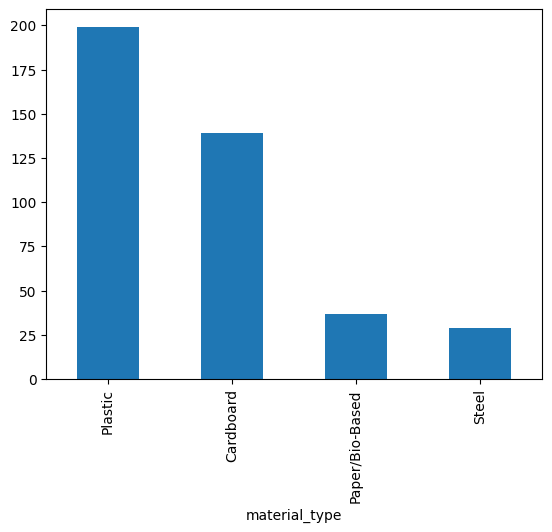

In [18]:
materials['material_type'].value_counts().plot(kind='bar')


Index(['strength_mpa', 'weight_capacity', 'biodegradability_percent',
       'co2_emission_score', 'recyclability_percent', 'cost_per_kg'],
      dtype='object')


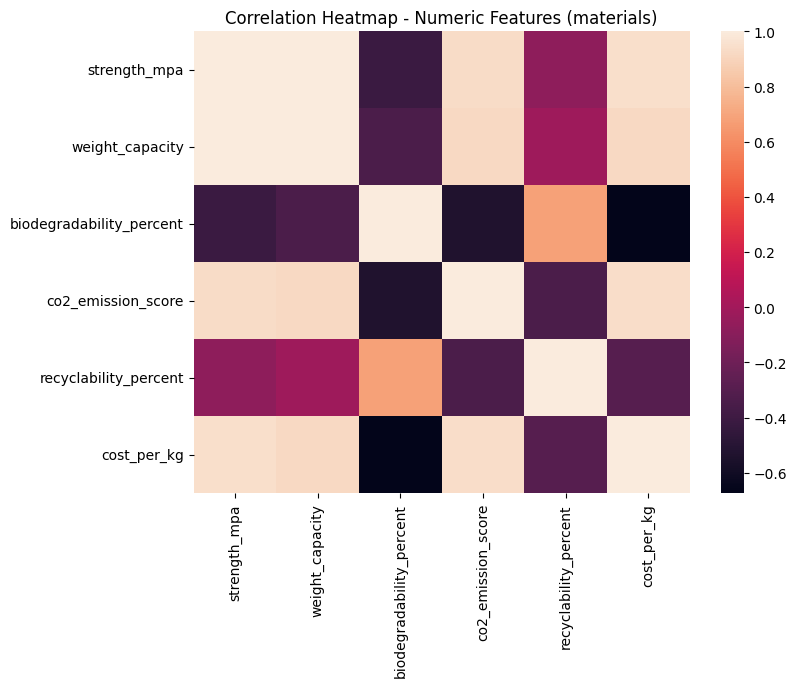

In [20]:
# Select only numeric columns
num_cols = materials.select_dtypes(include='number')

# Check which columns are numeric
print(num_cols.columns)

# Now compute correlation only on numeric columns
corr_matrix = num_cols.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False)
plt.title("Correlation Heatmap - Numeric Features (materials)")
plt.show()


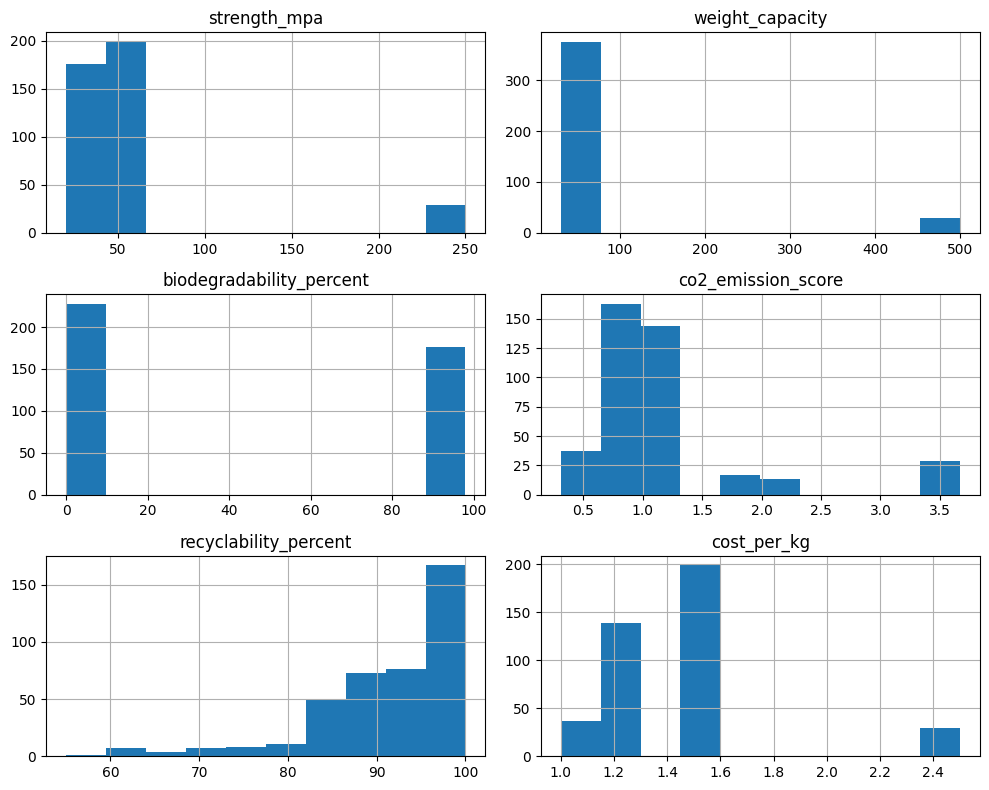

In [21]:
num_cols.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()
